In [72]:
import scanpy as sc
import pandas as pd
from sklearn import metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 

import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('/home/lytq/Spatial-Transcriptomics-Benchmark/utils')
from evaluate import evaluate_clustering
from load_st_data import load_colon_visium_hd

import time
import tracemalloc

import scipy.io
import json
import anndata as ad
import numpy as np

import SEDR

In [73]:
SEEDS = [42, 123, 456, 789, 2024]
random_seed = SEEDS[2]

In [74]:
data_path = Path('/home/lytq/Spatial-Transcriptomics-Benchmark/data/colon_cancer/')
sample_name = 'visium_hd_cancer_colon_square_016um'
qc = data_path / 'visium_hd_cancer_colon_square_016um' / 'qc'
spatial_dir = data_path / 'visium_hd_cancer_colon_square_016um' / 'spatial'

dir_input = data_path / sample_name
dir_output = Path(f'/home/lytq/Spatial-Transcriptomics-Benchmark/results/colon_cancer/{random_seed}/SEDR')
dir_output.mkdir(parents=True, exist_ok=True)

n_clusters = 6
device = 'cuda:4' if torch.cuda.is_available() else 'cpu'

In [75]:
X = scipy.io.mmread(qc / 'counts.mtx')
X.shape

(50387, 18051)

In [76]:
obs = pd.read_csv(qc / 'observations.tsv', sep='\t', index_col=0)
feat = pd.read_csv(qc / 'features.tsv', sep='\t', index_col=0)
print(len(obs))
print(len(feat))

50387
18051


In [77]:
obs.head()

,in_tissue,row,col,location_id,region,selected,n_genes,n_counts,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
s_016um_00010_00367-1,True,10,367,1,Visium_HD_Human_Colon_Cancer_square_016um,True,2394,4024.0,2394,4024.0,236.0,5.864811
s_016um_00163_00399-1,True,163,399,2,Visium_HD_Human_Colon_Cancer_square_016um,True,1068,1410.0,1068,1410.0,17.0,1.205674
s_016um_00144_00175-1,True,144,175,4,Visium_HD_Human_Colon_Cancer_square_016um,True,433,531.0,433,531.0,7.0,1.318267
s_016um_00050_00315-1,True,50,315,8,Visium_HD_Human_Colon_Cancer_square_016um,True,101,105.0,101,105.0,2.0,1.904762
s_016um_00000_00401-1,True,0,401,12,Visium_HD_Human_Colon_Cancer_square_016um,True,188,211.0,188,211.0,10.0,4.739336


In [78]:
feat.head()

,gene_ids,feature_types,genome,selected,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
SAMD11,ENSG00000187634,Gene Expression,GRCh38,True,395,False,395,0.008111,99.216658,409.0
NOC2L,ENSG00000188976,Gene Expression,GRCh38,True,1962,False,1962,0.040992,96.109073,2067.0
KLHL17,ENSG00000187961,Gene Expression,GRCh38,True,481,False,481,0.009678,99.046108,488.0
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38,True,933,False,933,0.019078,98.149727,962.0
PERM1,ENSG00000187642,Gene Expression,GRCh38,True,11,False,11,0.000218,99.978185,11.0


In [79]:
SEDR.fix_seed(random_seed)
adata, df_meta = load_colon_visium_hd(dir_input, spatial_dir)

Loading count matrix ...
Loaded 50387 spots x 18051 genes
Ground Truth
Neoplasm                     20887
Non-neoplastic Epithelium    15207
Connective Tissue            10614
Smooth Muscle                 1713
Vessel                        1044
Veins                          922
Name: count, dtype: int64


In [80]:
time_start = time.time()
tracemalloc.start()

# adata = sc.read_visium(dir_input)
# adata.var_names_make_unique()

# df_meta = pd.read_csv(os.path.join(dir_input, 'metadata.tsv'), sep='\t')
adata.layers['count'] = adata.X.toarray()
# adata.obs['layer_guess'] = df_meta['fine_annot_type'].values

# adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True].copy()
sc.pp.scale(adata)

adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

print('Start graph construction')
# graph_dict = SEDR.graph_construction(adata, 12)
graph_dict = SEDR.graph_construction(adata, 6)
    
print('Start SEDR training')
sedr_net = SEDR.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
using_dec = True
if using_dec:
    sedr_net.train_with_dec(N=1)
else:
    sedr_net.train_without_dec(N=1)
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat

SEDR.mclust_R(adata, n_clusters, use_rep='SEDR', key_added='SEDR', random_seed=random_seed)
print('Clustering finished')

# Evaluate clustering
time_taken = time.time() - time_start
current, peak = tracemalloc.get_traced_memory()
memory_used = peak / (1024 ** 2)
tracemalloc.stop()

results = evaluate_clustering(adata, df_meta, time_taken, memory_used, dir_output, 
                              pred_key='SEDR', gt_df_key='fine_annot_type')
print(f'ARI = {results["ARI"]:.4f}')

Start graph construction
Start SEDR training


100%|██████████| 200/200 [00:05<00:00, 37.04it/s]


fitting ...
  |======================================================================| 100%
Clustering finished
ARI = 0.3125


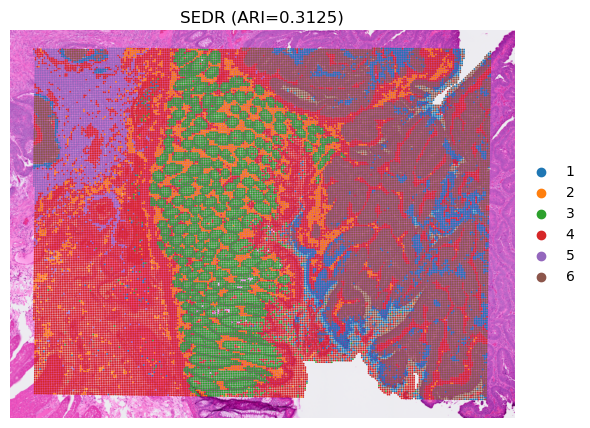

In [81]:
# Plot clustering
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(adata, color='SEDR', ax=axes, show=False)
axes.set_title(f'SEDR (ARI={results["ARI"]:.4f})')
axes.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(dir_output, 'clustering.pdf'), dpi=300, bbox_inches='tight')

In [82]:
sc.pp.neighbors(adata, use_rep='SEDR', metric='cosine')
sc.tl.umap(adata)

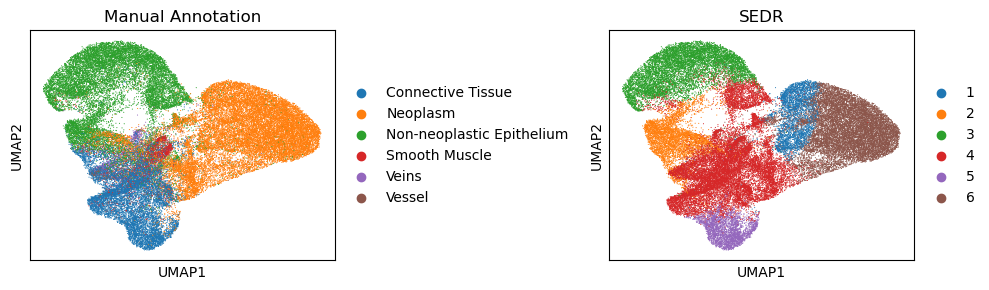

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sc.pl.umap(adata, color='Ground Truth', ax=axes[0], show=False)
sc.pl.umap(adata, color='SEDR', ax=axes[1], show=False)
axes[0].set_title('Manual Annotation')
axes[1].set_title('SEDR')
plt.tight_layout()
plt.savefig(os.path.join(dir_output, 'umap.pdf'), format='pdf', dpi=300, bbox_inches='tight')

In [84]:
low_dim_data = pd.DataFrame(adata.obsm['SEDR'], index=adata.obs.index)
# expression_data = pd.DataFrame(adata.layers['count'], index=adata.obs.index, columns=adata.var.index)
cell_metadata = adata.obs

low_dim_data.to_csv(f"{dir_output}/low_dim_data.csv")
# expression_data.T.to_csv(f"{dir_out}/expression_matrix.csv")
cell_metadata.to_csv(f"{dir_output}/cell_metadata.csv")

umap_coords = adata.obsm["X_umap"]
spot_ids = adata.obs_names
umap_df = pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
umap_df["spot_id"] = spot_ids
umap_df = umap_df[["spot_id", "UMAP1", "UMAP2"]]
umap_df.to_csv(os.path.join(dir_output, "spatial_umap_coords.csv"), index=False)
